In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

/home/ahmed/miniconda3/envs/ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("documents/data/AI_Engineer-page1.pdf").load()
    + PyPDFLoader("documents/data/Tanvir_Ahmed_Enterprise_Demo_RAG_Knowledge_Base.pdf").load()
    + PyPDFLoader("documents/data/Tanvir_Ahmed_RAG_Knowledge_Base.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [6]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [7]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]     # New

    answer: str

In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [10]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

def generate(state: State):

    context = "\n\n".join(
        doc.page_content
        for doc in state["docs"]
    )

    response = llm.invoke(
        f"""
        Answer the question using ONLY the context.

        Context:
        {context}

        Question:
        {state["question"]}
        """
    )

    return {
        "answer": response.content
    }

In [11]:
# New

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}



In [27]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

# New
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found."}

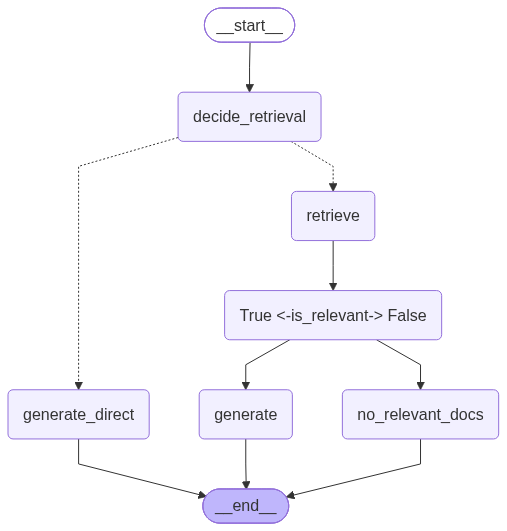

In [31]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("True <-is_relevant-> False", is_relevant) # New
g.add_node("generate", generate)
g.add_node("no_relevant_docs", no_relevant_docs)


# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", "True <-is_relevant-> False") # New
g.add_edge("True <-is_relevant-> False", "no_relevant_docs") # New
g.add_edge("no_relevant_docs",END) # New
g.add_edge("True <-is_relevant-> False","generate") # New
g.add_edge("generate", END) # New

app = g.compile()
app

In [16]:
result = app.invoke(
    {
        "question": "Who is the Founder of DSwithBappy",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

The context does not provide information about the founder of DSwithBappy.


In [17]:
result['need_retrieval']

True

In [24]:
result = app.invoke(
    {
        "question": "who is tanvir ahmed",
        "need_retrieval":"",
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])
print(result['need_retrieval'])
# print(result['docs'])

Tanvir Ahmed is an AI Engineer / Machine Learning Engineer specializing in end-to-end AI systems across Machine Learning, Deep Learning, Computer Vision, Generative AI, Retrieval-Augmented Generation (RAG), and MLOps.
True


In [ ]:
result = app.invoke(
    {
        "question": "what is llm",
        "need_retrieval":"",
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

LLM can refer to a few different things depending on the context:

1. **Master of Laws (LL.M.)**: This is a postgraduate academic degree in law. It is typically pursued by individuals who already hold a first degree in law and wish to specialize in a particular area of legal study.

2. **Large Language Model (LLM)**: In the context of artificial intelligence and natural language processing, an LLM refers to a type of AI model that is trained on vast amounts of text data to understand and generate human-like language. Examples include models like GPT-3 and BERT.

If you have a specific context in mind, please clarify!


In [23]:
result['need_retrieval']


False

In [18]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

 Manage cloud deployment.
 Support ML model monitoring.
---
9. Company Profile — DataVision Labs
Company ID: COM-002
Company Name: DataVision Labs
Industry: Data Science and AI
Head Office: Rome, Italy
Founded: 2020
Employee Count: 96
Departments
 Data Science
 Computer Vision
 NLP
 Data Engineering
 MLOps
 Product
Example Employees
Employee DV-001
Name: Giulia Moretti
****************************************************************************************************
Tanvir Ahmed — Enterprise Demo RAG Knowledge Base
Page 10
13. Employee Project Assignments
Tanvir Ahmed
Project A — NeuroVision AI
Project Type: Medical AI
Role: Lead Developer
Department: AI & ML
Technologies: TensorFlow, VGG16, YOLO, SAM, FastAPI, Pinecone, AWS, OpenAI.
Project B — Multimodal RAG
Project Type: Generative AI
Role: AI Engineer
Department: Generative AI
Technologies: OpenAI Vision, Pinecone, LangChain, Python, AWS.
Project C — Medical AI Assistant
Project Type: Healthcare RAG
Role: AI Engineer
Depa

In [19]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

In [20]:
result['relevant_docs']

[]